In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import scipy
import scipy.ndimage
import torch
from tqdm import tqdm

from grid_pattern_formation.evals.core import build_eval_context, get_cached_ratemaps
from grid_pattern_formation.evals.analysis_connectivity import compute_phase_order, compute_jmean, compute_phase_original_order
from grid_pattern_formation.evals.analysis_dynamics import get_fourier_spectrum, find_peak_coordinates
from grid_pattern_formation.evals.analysis_core import compute_grid_scores
from grid_pattern_formation.utils.two_d_sort import get_2d_sort

%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

baseline_ctx = build_eval_context(
    checkpoint_path="../checkpoints/replicate_baseline_colab_orig_rmsprop_alive.pth",
    config_path="../configs/replicate_baseline_colab_orig_rmsprop_alive.yaml",
    results_root="../results/phase_analysis",
)
topo_ctx = build_eval_context(
    checkpoint_path="../checkpoints/cos_decay_hw4_final_model.pth",
    config_path="../configs/topo_cos_decay_hw4.yaml",
    results_root="../results/phase_analysis",
)

RES = 50
N_AVG = 100
Ng = 4096
n = int(np.sqrt(Ng))

print("Baseline ratemaps")
baseline_act, baseline_rm, baseline_g, baseline_pos = get_cached_ratemaps(baseline_ctx, res=RES, n_avg=N_AVG, ng=Ng)
print("Topoloss ratemaps")
topo_act, topo_rm, topo_g, topo_pos = get_cached_ratemaps(topo_ctx, res=RES, n_avg=N_AVG, ng=Ng)

baseline_order, baseline_phases = compute_phase_order(baseline_ctx, baseline_rm, RES)
topo_order, topo_phases = compute_phase_original_order(topo_ctx, topo_rm, RES)

J_baseline = baseline_ctx.model.RNN.weight_hh_l0.detach().cpu().numpy().T
J_topo = topo_ctx.model.RNN.weight_hh_l0.detach().cpu().numpy().T

J_baseline_sorted = J_baseline[baseline_order][:, baseline_order]

_, baseline_imroll_sorted = compute_jmean(J_baseline_sorted, n)
_, baseline_imroll_unsorted = compute_jmean(J_baseline, n)
_, topo_imroll_unsorted = compute_jmean(J_topo, n)

print("Baseline grid scores")
baseline_scores = compute_grid_scores(baseline_ctx)
print("Topoloss grid scores")
topo_scores = compute_grid_scores(topo_ctx)

Baseline ratemaps
Topoloss ratemaps
Baseline grid scores


Grid scores:   0%|          | 0/4096 [00:00<?, ?it/s]/Volumes/LaCie SSD/Documents/MurtyLab/grid-pattern-formation/grid_pattern_formation/evals/grid_scores.py:115: RuntimeWarning: invalid value encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))
Grid scores: 100%|██████████| 4096/4096 [00:12<00:00, 338.57it/s]


Topoloss grid scores


Grid scores: 100%|██████████| 4096/4096 [00:12<00:00, 337.24it/s]


(np.float64(-2.5500000000000003),
 np.float64(53.55),
 np.float64(-1.4722431864335457),
 np.float64(30.91710691510446))

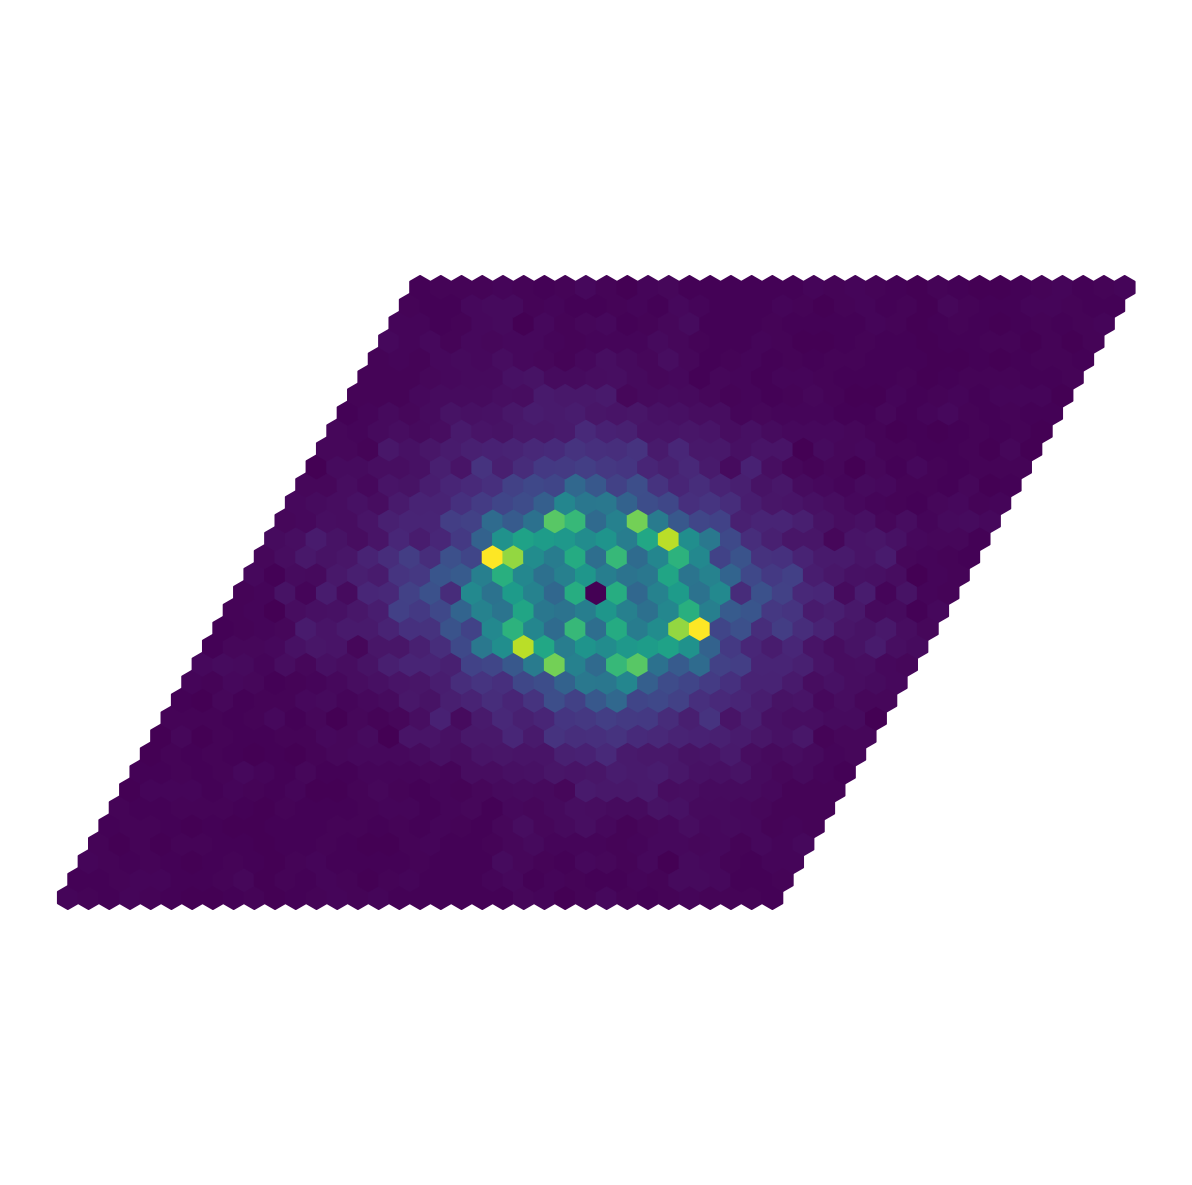

In [2]:
n = 64
width = 18
xs = np.arange(2*width-1)
X,Y = np.meshgrid(xs,xs)
XY = np.stack((X.ravel(),Y.ravel()),0)
T = np.array([[1,0.5],[0,np.sqrt(3)/2]])
XY = T.dot(XY)

J_square = np.reshape(J_topo, (n,n,n,n))

Jmean = np.zeros([n,n])
for i in range(n):
    for j in range(n):
        Jmean += np.roll(np.roll(J_square[i,j], -i, axis=0), -j, axis=1)
        
Jmean[0,0] = np.max(Jmean[1:,1:])
Jmean = np.roll(np.roll(Jmean, n//2, axis=0), n//2, axis=1)

A = np.asarray([[2, 1], [0, np.sqrt(3)]]) / 2
Ainv = np.linalg.inv(A)

im = scipy.ndimage.affine_transform(Jmean, Ainv, mode='wrap')

idxs = np.arange(-width+1, width)
im_fft = np.abs(np.fft.fft2(im))
im_fft[0,0] = 0

plt.figure(figsize=(10,10))
plt.scatter(XY[0],XY[1],s=120,c=im_fft[idxs][:,idxs].ravel(),
            marker='h', cmap='viridis')
plt.axis('equal')
plt.axis('off')

(np.float64(-2.5500000000000003),
 np.float64(53.55),
 np.float64(-1.4722431864335457),
 np.float64(30.91710691510446))

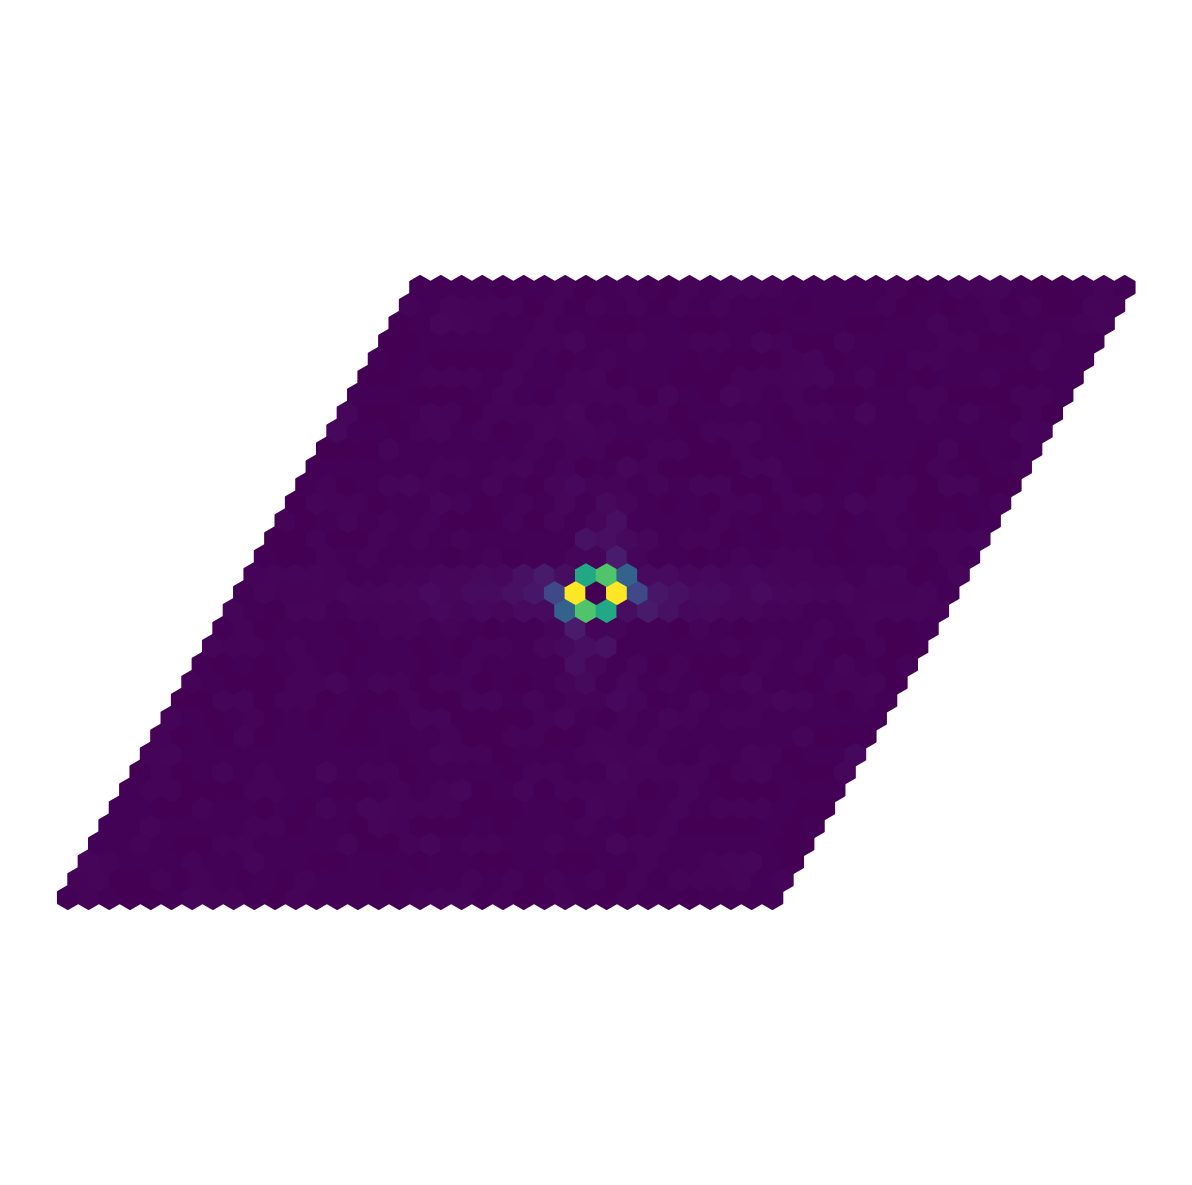

In [3]:
n = 64
width = 18
xs = np.arange(2*width-1)
X,Y = np.meshgrid(xs,xs)
XY = np.stack((X.ravel(),Y.ravel()),0)
T = np.array([[1,0.5],[0,np.sqrt(3)/2]])
XY = T.dot(XY)

J_square = np.reshape(J_baseline_sorted, (n,n,n,n))

Jmean = np.zeros([n,n])
for i in range(n):
    for j in range(n):
        Jmean += np.roll(np.roll(J_square[i,j], -i, axis=0), -j, axis=1)
        
Jmean[0,0] = np.max(Jmean[1:,1:])
Jmean = np.roll(np.roll(Jmean, n//2, axis=0), n//2, axis=1)

A = np.asarray([[2, 1], [0, np.sqrt(3)]]) / 2
Ainv = np.linalg.inv(A)

im = scipy.ndimage.affine_transform(Jmean, Ainv, mode='wrap')

idxs = np.arange(-width+1, width)
im_fft = np.abs(np.fft.fft2(im))
im_fft[0,0] = 0

plt.figure(figsize=(10,10))
plt.scatter(XY[0],XY[1],s=120,c=im_fft[idxs][:,idxs].ravel(),
            marker='h', cmap='viridis')
plt.axis('equal')
plt.axis('off')